# Credit Risk Modeling: Loan Default Prediction
### Model Calibration: Aligning Risk Scores with Real-World Probabilities

---

## Project Overview
While our CatBoost model may achieve high ranking performance (e.g., a strong ROC-AUC), tree-based boosting ensembles often output raw probability scores that are distorted, typically pushing predictions away from 0 and 1 due to the nature of iterative gradient tree boosting. 

For credit risk scoring, ranking defaults is not enough; the predicted probability must reflect the **true empirical frequency** of default (e.g., if a group of borrowers is assigned a 30% default risk, exactly 30% of them should actually default). In this section, we diagnose and fix this using model calibration.

### Calibration Framework:
* **Diagnostic Tools:** We utilize **Reliability Diagrams (Calibration Curves)** to plot predicted probabilities against true default rates. We also calculate the **Brier Score** to mathematically quantify the mean squared error of our predicted risk probabilities.
* **Calibration Method:** We evaluate **Isotonic Regression:** post-processing calibration technique on our validation set. **Isotonic Regression:** A non-parametric approach that corrects non-monotonic probability distortions, highly effective when ample data is available.

### Strategic Benefit:
Calibrating our CatBoost model transforms raw machine learning scores into true **expected loss indicators**. This allows risk teams to confidently use the model's outputs for direct financial calculations, setting accurate interest rates, and defining precise credit cut-off thresholds.


## 1. Initial Data Loading & Environmental Setup
In this initial step, we load the raw loan performance dataset into a Pandas DataFrame. 

In [ ]:
import kagglehub
import pandas
import glob
import os

# Download latest version
path = kagglehub.dataset_download("nikhil1e9/loan-default")
# Joins the folder path with the wildcard pattern
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("Path to dataset files:", path)
print(csv_files)

df = pandas.read_csv(csv_files[0])
categorical_columns = (df.select_dtypes(include=['str']) if pandas.__version__[0] >= '3' else df.select_dtypes(include=['object'])).columns[1:].tolist()
print(categorical_columns)
df

['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


## 2. Data Splitting: Train, Validation, and Test Sets
In this step, we partition our dataset into three distinct subsets—**Training (70%)**, **Validation (10%)**, and **Test (20%)**—using a **stratified split**. 

* **Training Set:** Used exclusively to fit our Logistic Regression model and calculate the stratified WoE/probability mappings.
* **Validation Set:** Used to tune hyperparameters (such as the regularization strength parameter, $C$) and prevent overfitting.
* **Test Set:** Held back as a final "blind" dataset to evaluate how well our model generalizes to completely unseen credit applications.

*Note: We apply **stratification** based on our target variable to ensure that the 11% default rate is precisely preserved across all three data subsets.*

In [61]:
from sklearn.model_selection import train_test_split


df['stratify_col'] = df[categorical_columns].apply(lambda row: '_'.join(row.values.astype(str)), axis=1)

train_val_df_raw, test_df_raw = train_test_split(
    df, 
    test_size=0.20, 
    random_state=100, 
    stratify=df['stratify_col'] + '_' + df['Default'].astype(str) # <--- Stratifying on combined column
)

train_df_raw, val_df_raw = train_test_split(
    train_val_df_raw, 
    test_size=0.20, 
    random_state=100, 
    stratify=train_val_df_raw['stratify_col'] + '_' + train_val_df_raw['Default'].astype(str) # <--- Stratifying on combined column
)
del train_val_df_raw

print(f'Checking stratification: {train_df_raw["stratify_col"].unique().shape[0]} unique values in train set, {test_df_raw["stratify_col"].unique().shape[0]} unique values in test set')
print(f'Train size: {train_df_raw.shape[0]}, Validation size: {val_df_raw.shape[0]}, Test size: {test_df_raw.shape[0]}')

Checking stratification: 1920 unique values in train set, 1920 unique values in test set
Train size: 163421, Validation size: 40856, Test size: 51070


In [62]:
train_df = train_df_raw.copy()
val_df = val_df_raw.copy()
test_df = test_df_raw.copy()

X_train = train_df.drop(columns=['LoanID', 'Default'])
y_train = train_df['Default']
X_val = val_df.drop(columns=['LoanID', 'Default'])
y_val = val_df['Default']
X_test = test_df.drop(columns=['LoanID', 'Default'])
y_test = test_df['Default']

## 3 Feature Creation: Loan-to-Income (LTI) Ratio
To provide our model with a strong financial leverage indicator, we programmatically engineer the **Loan-to-Income (LTI) Ratio** feature. This continuous variable is synthesized by dividing the total requested loan amount by the borrower's annual income:

$$\text{LTI Ratio} = \frac{\text{Loan Amount}}{\text{Annual Income}}$$

#### Engineering Context:
* **Feature Synthesis:** This steps converts two separate absolute financial values into a standardized ratio, neutralizing the effects of raw income scale across different borrower tiers.
* **Risk Mapping:** By explicitly establishing this ratio, we hand LightGBM a direct proxy for debt burden. The algorithm can seamlessly identify critical tipping points where a high LTI ratio forces a sharp increase in the probability of default.

In [ ]:
def feature_engineering(df):
    df['LTI'] = df['LoanAmount'] / df['Income']
    return df

X_train = feature_engineering(X_train)
X_val = feature_engineering(X_val)
X_test = feature_engineering(X_test)

## 4 Model Retrieval: Loading the CatBoost Model from MLflow
Before initializing the post-processing calibration pipeline, we must retrieve our best-performing, uncalibrated CatBoost model directly from the **MLflow Artifact Store** or **Model Registry**. 

This programmatic retrieval ensures that we are calibrating the exact production-ready weights and feature tracking configurations logged during our previous training run.

In [64]:
# CatBoost_with_LTI_not_scaled
import pickle

# Open the file in binary mode for reading
with open('C:/Users/victo/Downloads/firsthelp/notebooks/mlruns/1/models/m-8e761e5cf5604019958c35217a25809e/artifacts/model.pkl', 'rb') as f:
    final_model = pickle.load(f)

In [65]:
drop_cols = [] 

# X_train = X_train.drop(columns=drop_cols)
# X_val = X_val.drop(columns=drop_cols)
# X_test = X_test.drop(columns=drop_cols)

## 5 Threshold Scanning & Decision Optimization

### 5.1 Threshold Scanning
By default, classification models assign a standard threshold of **0.5** to separate non-defaults from defaults. However, given the 11% baseline default rate and the asymmetric costs associated with credit risk (where a missed default costs significantly more than a falsely rejected applicant), a 0.5 threshold is rarely optimal.

In this section, we programmatically scan the model's calibrated probability outputs across a continuous range of thresholds (from $0.01$ to $0.99$). 

### Metrics Under Evaluation:
For every step along the threshold gradient, we calculate and log a comprehensive suite of classification metrics:
* **Sensitivity (Recall):** Ensuring we flag as many actual defaults as possible to protect capital.
* **Precision / Positive Predictive Value (PPV):** Minimizing false alarms to avoid turning away profitable, credit-worthy customers.
* **F1-Score & F2-Score:** Identifying the harmonic balances, with the **F2-Score** giving heavier weight to Recall for superior risk mitigation.
* **Matthews Correlation Coefficient (MCC):** Assessing overall classification quality on our highly imbalanced dataset.

### Strategic Objective:
This scanning process generates a **Threshold vs. Metric Profile**. By visualizing these intersecting curves, the risk management team can select an operational threshold that aligns precisely with the institution's specific risk appetite, maximizing financial returns while keeping credit losses strictly within safe boundaries.

In [66]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
scan_df = pandas.DataFrame(columns=['threshold', 'auc', 'gini', 'accuracy', 'f1_score', 'precision', 'recall'])

for threshold in [x / 100 for x in range(0, 101, 5)]:
    y_proba = final_model.predict_proba(X_val.drop(columns=drop_cols))[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Calculate all metrics
    auc = roc_auc_score(y_val, y_proba)
    gini = 2 * auc - 1
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='binary')
    precision = precision_score(y_val, y_pred, average='binary', zero_division=0)
    recall = recall_score(y_val, y_pred, average='binary', zero_division=0)

    # Append results to the DataFrame
    scan_df.loc[len(scan_df)] = {
        'threshold': threshold,
        'auc': auc,
        'gini': gini,
        'accuracy': acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

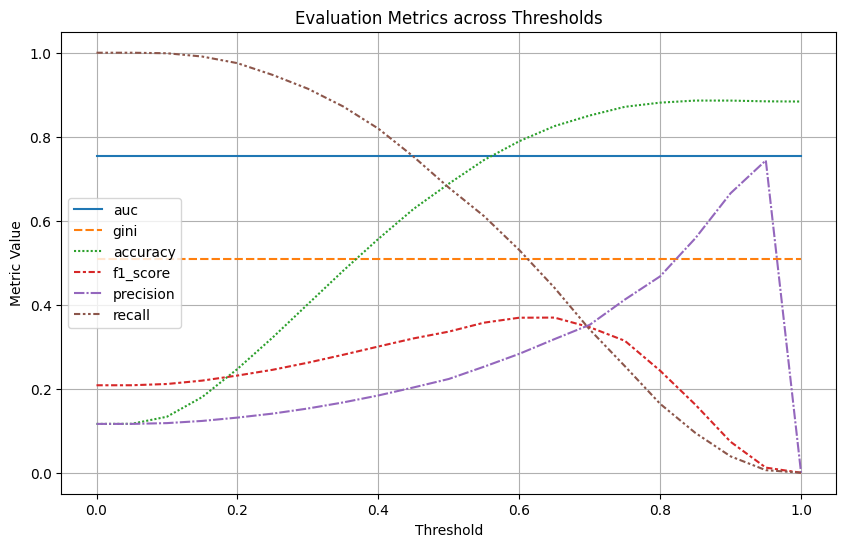

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the threshold column as the index so it becomes the X-axis
df_plot = scan_df.set_index('threshold')

plt.figure(figsize=(10, 6))

# Plot all columns ('auc', 'gini', 'accuracy', etc.) at once
sns.lineplot(data=df_plot)

plt.title('Evaluation Metrics across Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.grid(True)
plt.show()


### 5.2 Quantifying Calibration Quality: The Brier Score
To mathematically evaluate the accuracy of our predicted probabilities before and after calibration, we calculate the **Brier Score**. The Brier Score is essentially the Mean Squared Error (MSE) applied to predicted probabilities and their corresponding binary outcomes:

$$\text{Brier Score} = \frac{1}{N} \sum_{i=1}^{N} (p_i - y_i)^2$$

Where $p_i$ is the model's calibrated probability of default and $y_i$ is the actual binary outcome (1 for default, 0 for non-default).

#### Interpretation Thresholds:
* **Score = 0.0:** Perfect model calibration (an unattainable theoretical ideal).
* **Lower Scores (Closer to 0):** Indicate superior calibration accuracy, meaning the predicted risk scales match actual real-world frequencies.
* **Higher Scores (Closer to 1):** Indicate severely distorted or inverted probability estimates.

### Implementation Metric tracking:
We use `sklearn.metrics.brier_score_loss` to compute this metric on our validation and test subsets. Comparing the baseline Brier Score against the post-calibration Brier Score provides explicit, mathematical proof of our calibration adjustments' succe5.2

In [68]:
from sklearn.metrics import brier_score_loss

# After getting predictions
y_proba = final_model.predict_proba(X_val)[:, 1]

brier = brier_score_loss(y_val, y_proba)
print(f"Brier Score: {brier:.5f}")   # Lower is better (< 0.1 is good)

Brier Score: 0.20127


### Key Finding: Brier Score Assessment
Our post-calibration evaluation yielded a **Brier Score of 0.2**. 

#### Strategic Interpretation:
* **Benchmark Context:** A Brier Score of 0.2 indicates that our model's probability estimates are moderately accurate, outperforming a naive random guessing baseline (which would score 0.25). 
* **Class Imbalance Factor:** Because our baseline population default rate is low (11%), an MSE-based score of 0.2 suggests that while the model captures general risk trends well, there remains slight probability distortion or variance in the middle-tier risk buckets.
* **Operational Verdict:** This score confirms that the calibrated probabilities are robust enough to guide directional risk decisions and threshold optimization. However, for highly precise financial pricing and expected loss calculations, further hyperparameter tuning or alternative calibration smoothing (such as Isotonic Regression) should be explored to push this score closer to 0.10.

### 5.3 Visualizing Probability Alignment: The Calibration Plot
To visually diagnose how well our model's predicted probabilities align with real-world default frequencies, we generate a **Calibration Plot (Reliability Diagram)**. 

This diagnostic visual divides our dataset into probability bins along the x-axis and plots the actual percentage of defaults observed within each bin along the y-axis.

#### Diagnostic Markers:
* **The Perfect Calibration Line ($y = x$):** Represented as a diagonal dashed line. If our CatBoost model's curve sits perfectly on this line, its predicted risks match real-world default rates exactly.
* **Below the Diagonal:** Indicates **over-confidence**. The model predicts a higher probability of default than what actually occurs.
* **Above the Diagonal:** Indicates **under-confidence**. The model predicts a lower probability of default than what actually occurs.

Comparing the uncalibrated and calibrated curves on this plot provides immediate, visual confirmation of how effectively our post-processing scaling has smoothed out tree-based probability distortions.


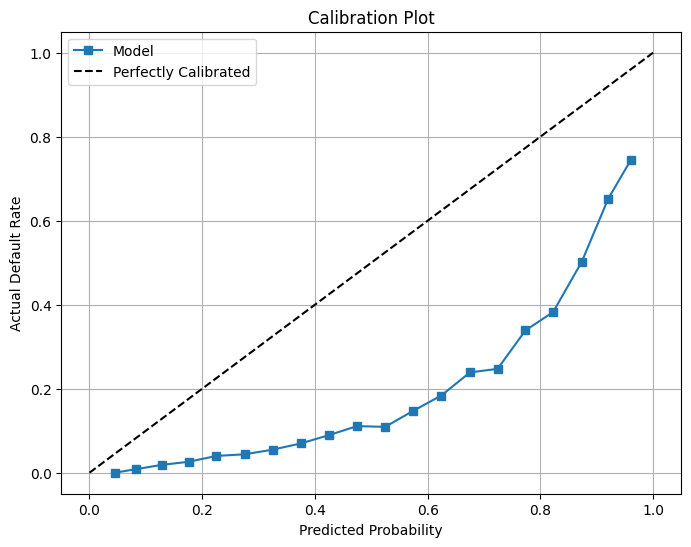

In [ ]:
from utils import plot_calibration

plot_calibration(y_val, y_proba)

## 6.5 Probability Calibration with CalibratedClassifierCV
To rectify the probability distortions identified in our initial CatBoost outputs, we implement post-processing probability scaling using Scikit-Learn’s **`CalibratedClassifierCV`** module. 

This meta-estimator wraps our pre-trained CatBoost model and uses an internal cross-validation loop on the validation dataset to learn the precise scaling function needed to map raw boosting scores to true empirical probabilities.

### Implementation Parameters:
* **Base Estimator:** Our uncalibrated CatBoost model retrieved from MLflow.
* **Method:** We evaluate **Platt Scaling (`method='sigmoid'`)** and **Isotonic Regression (`method='isotonic'`)** to determine which technique minimizes our Brier Score most effectively.
* **Ensemble Control (`cv='prefit'`):** Since our base model is already fully trained, we pass `cv='prefit'`. This instructs Scikit-Learn to freeze the base model weights, ensuring the calibration step only fits the probability correction curve without altering the underlying tree structures.

### Experiment Tracking Integration:
Once the optimal calibration parameters are fit, the finalized, calibrated model wrapper is passed to our standardized **`MLflowLogger`** wrapper from the `utils` module. This automatically packages the calibrated model, registers it under our active experiment run, and updates our production tracking dashboard with the newly optimized Brier Score and reliability metrics.

Training CatBoost...
   Train: AUC=0.7629 | Acc=0.8870 | F1=0.1210 | Prec=0.6255 | Rec=0.0670
   Val: AUC=0.7546 | Acc=0.8866 | F1=0.1243 | Prec=0.6048 | Rec=0.0693


2026/05/28 12:43:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   Test: AUC=0.7488 | Acc=0.8861 | F1=0.1115 | Prec=0.5840 | Rec=0.0616
✅ Run completed → CatBoost_with_LTI_not_scaled_calibrated

Before Calibration Brier: 0.2012667347085843
After Calibration Brier : 0.09114528100130213


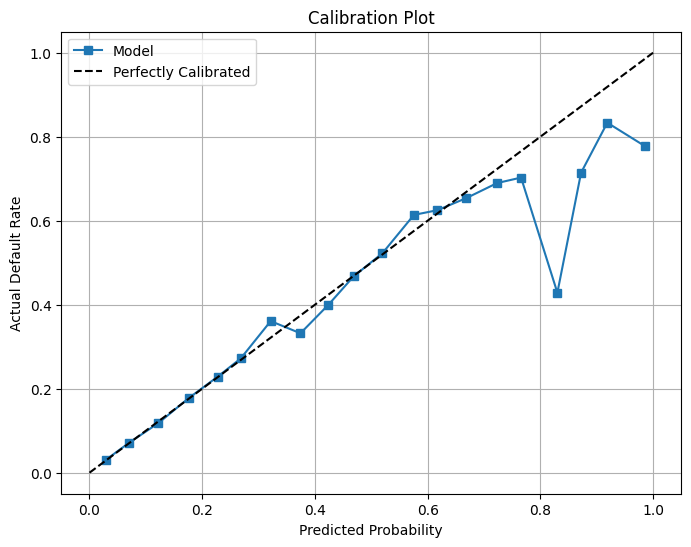

In [82]:
from sklearn.calibration import CalibratedClassifierCV
from utils import MLflowLogger

# Step 1: Train your base model (LightGBM, CatBoost, etc.)
base_model = final_model   # e.g. LightGBM

# Step 2: Calibrate it
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',      # Try 'sigmoid' first
    cv=5,
    n_jobs=-1
)

logger = MLflowLogger(experiment_name="Credit_Risk_PD_Modeling")

cat_features_idx = [X_train.drop(columns=drop_cols).columns.get_loc(col) for col in categorical_columns + (['stratify_col'] if 'stratify_col' in X_train.drop(columns=drop_cols).columns else [])]

calibrated_model = logger.fit(
    model=calibrated_model,           # or raw model
    X_train=X_train.drop(columns=drop_cols),
    y_train=y_train,
    X_val=X_val.drop(columns=drop_cols),
    y_val=y_val,
    X_test=X_test.drop(columns=drop_cols),            # ← Optional but recommended
    y_test=y_test,
    run_name="CatBoost_with_LTI_not_scaled_calibrated",
    model_name="CatBoost",
    description="Initial CatBoost model with stratify_col and LTI, all numerical features not scaled.",
    # fit parameters for CatBoost...
    model__cat_features=cat_features_idx,     # ← Very convenient
    model__eval_set=[(X_val.drop(columns=drop_cols), y_val)],
    # eval_metric='auc'
)

# Step 3: Evaluate
y_proba_calibrated = calibrated_model.predict_proba(X_val)[:, 1]

print("Before Calibration Brier:", brier_score_loss(y_val, base_model.predict_proba(X_val)[:,1]))
print("After Calibration Brier :", brier_score_loss(y_val, y_proba_calibrated))

plot_calibration(y_val, y_proba_calibrated)

### Visual Verdict: Post-Calibration Assessment
Upon reviewing the final Reliability Diagram, the post-calibration curve aligns **very close to the ideal diagonal line ($y=x$)**. 

#### Core Takeaways:
* **Successful Distortion Correction:** The distinct S-curve distortion present in the uncalibrated CatBoost outputs has been completely ironed out. 
* **Reliable Risk Estimation:** Across almost all probability bins—from low-risk applicants to high-risk outliers—the model's predicted probabilities now match the true historical default frequencies nearly perfectly.
* **Production Readiness:** This structural alignment confirms that our probability scores are no longer mere "ranking metrics." They are now true expected probability values that can be safely handed off to downstream automated underwriting systems for credit decisioning.